<a href="https://colab.research.google.com/github/prajwalp111/monai/blob/main/Hackathon_DRIVE_Segmentation_Pipeline_(Tasks_1_%26_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================================
# HACKATHON DRIVE SEGMENTATION PIPELINE - MONAI & LOCAL DATA
# Focusing on DRIVE dataset (2D Retinal Vessel Segmentation)
# FIX: Replaced UNetPlusPlus with AttentionUnet to resolve ImportError
# FIX: Updated handlers for MONAI >=1.3
# =============================================================================

# 1. SETUP AND INSTALLATIONS
# --------------------------
print("1. Installing required libraries...")
!pip install -q monai[nibabel,ignite]
print("Installation complete. Importing modules...")

import os
import glob
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, Compose,
    Resize, NormalizeIntensityd, ScaleIntensityd,
    RandFlipd, RandRotated, RandZoomd,
    RandGaussianSmoothd, RandAdjustContrastd
)
from monai.data import list_data_collate
from monai.networks.nets import UNet, AttentionUnet
from monai.losses import DiceLoss
from monai.engines import SupervisedTrainer
from monai.handlers import CheckpointSaver, StatsHandler, EarlyStopHandler, LrScheduleHandler
from monai.metrics import DiceMetric
from monai.utils import set_determinism
from sklearn.model_selection import train_test_split

1. Installing required libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 23.9 MB/s eta 0:00:00
Installation complete. Importing modules...


In [2]:
# Set device and determinism
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
set_determinism(seed=42)

# 2. DATA PREPARATION
# -------------------
def get_monai_datalist(data_dir):
    """
    Returns MONAI-compatible dictionary list for DRIVE dataset.
    Expects structure:
    DRIVE/
        training/images/
        training/1st_manual/   <-- masks
    """
    image_files = sorted(glob.glob(os.path.join(data_dir, 'training', 'images', '*.tif')))
    label_files = sorted(glob.glob(os.path.join(data_dir, 'training', '1st_manual', '*.gif')))

    if len(image_files) == 0 or len(label_files) == 0:
        raise ValueError(f"No images or labels found!\nImages: {image_files}\nLabels: {label_files}")

    data_dicts = [{"image": img, "label": lbl} for img, lbl in zip(image_files, label_files)]
    train_data, val_data = train_test_split(data_dicts, test_size=0.2, random_state=42)
    return train_data, val_data

Using device: cpu


In [4]:
!git clone https://github.com/prajwalp111/monai.git /content/monai_repo


Cloning into '/content/monai_repo'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 121 (delta 3), reused 113 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 27.99 MiB | 33.87 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [8]:


from monai.transforms import Resized




# Replace with your local GitHub DRIVE folder path
DRIVE_PATH = "/content/monai_repo/DRIVE"
drive_train_files, drive_val_files = get_monai_datalist(DRIVE_PATH)


print(f"\nTotal Samples: {len(drive_train_files) + len(drive_val_files)}")
print(f"Training Samples: {len(drive_train_files)}")
print(f"Validation Samples: {len(drive_val_files)}")

# 3. DATA PREPROCESSING & AUGMENTATION
# ------------------------------------
print("\n3. TASK 1: Data Preprocessing & Augmentation Setup")

# Custom augmentations
drive_custom_transforms = [
    RandAdjustContrastd(keys=["image"], prob=0.5, gamma=(0.8, 1.2)),
    RandGaussianSmoothd(keys=["image"], prob=0.5, sigma_x=(0.5, 1.5))
]

# Training transforms
DRIVE_TRAIN_TRANSFORM = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityd(keys=["image"]),
        Resized(keys=["image", "label"], spatial_size=(512, 512), mode=("bilinear", "nearest"))
,
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandRotated(keys=["image", "label"], range_x=np.pi / 4, prob=0.5, mode=("bilinear", "nearest")),
    RandZoomd(keys=["image", "label"], min_zoom=0.9, max_zoom=1.1, prob=0.5, mode=("bilinear", "nearest")),
    *drive_custom_transforms,
])





Total Samples: 20
Training Samples: 16
Validation Samples: 4

3. TASK 1: Data Preprocessing & Augmentation Setup


In [9]:
# Validation transforms
DRIVE_VAL_TRANSFORM = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image", "label"], spatial_size=(512, 512), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
])

# Visualization function
def visualize_transforms(data_list, transform_pipeline, num_samples=3, dataset_name="Dataset"):
    fig, axes = plt.subplots(num_samples, 4, figsize=(15, 5 * num_samples))
    fig.suptitle(f'{dataset_name} Preprocessing & Augmentation Effects', fontsize=16)

    for i in range(num_samples):
        original = LoadImaged(keys=["image", "label"])(data_list[i])
        orig_img = np.asarray(original['image'])[0]
        orig_lbl = np.asarray(original['label'])[0]

        transformed = transform_pipeline(data_list[i])
        t_img = np.squeeze(transformed['image'])
        t_lbl = np.squeeze(transformed['label'])

        axes[i, 0].imshow(orig_img, cmap='gray'); axes[i, 0].set_title("Original Image"); axes[i, 0].axis('off')
        axes[i, 1].imshow(orig_lbl, cmap='jet'); axes[i, 1].set_title("Original Label"); axes[i, 1].axis('off')
        axes[i, 2].imshow(t_img, cmap='gray'); axes[i, 2].set_title("Transformed Image"); axes[i, 2].axis('off')
        axes[i, 3].imshow(t_lbl, cmap='jet'); axes[i, 3].set_title("Transformed Label"); axes[i, 3].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

In [11]:


# Prepare data lists
drive_train_files, drive_val_files = get_monai_datalist(DRIVE_PATH)

print(f"\nDRIVE Total Samples: {len(drive_train_files) + len(drive_val_files)}")
print(f"DRIVE Training Samples (subset): {len(drive_train_files)}")
print(f"DRIVE Validation Samples (subset): {len(drive_val_files)}")


DRIVE Total Samples: 20
DRIVE Training Samples (subset): 16
DRIVE Validation Samples (subset): 4


In [13]:
!pip install tifffile imageio



In [14]:
from monai.config import print_config
print_config()


MONAI version: 1.5.1
Numpy version: 2.0.2
Pytorch version: 2.8.0+cu126
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 9c6d819f97e37f36c72f3bdfad676b455bd2fa0d
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.2
scikit-image version: 0.25.2
scipy version: 1.16.2
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.0
TorchVision version: 0.23.0+cu126
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.1
transformers version: 4.56.1
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#inst

RuntimeError: LoadImage cannot find a suitable reader for file: /content/monai_repo/DRIVE/training/images/29_training.tif.
    Please install the reader libraries, see also the installation instructions:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies.
   The current registered: [<monai.data.image_reader.NumpyReader object at 0x7dc2148d6330>, <monai.data.image_reader.PILReader object at 0x7dc214c96570>, <monai.data.image_reader.NibabelReader object at 0x7dc2196ac920>].


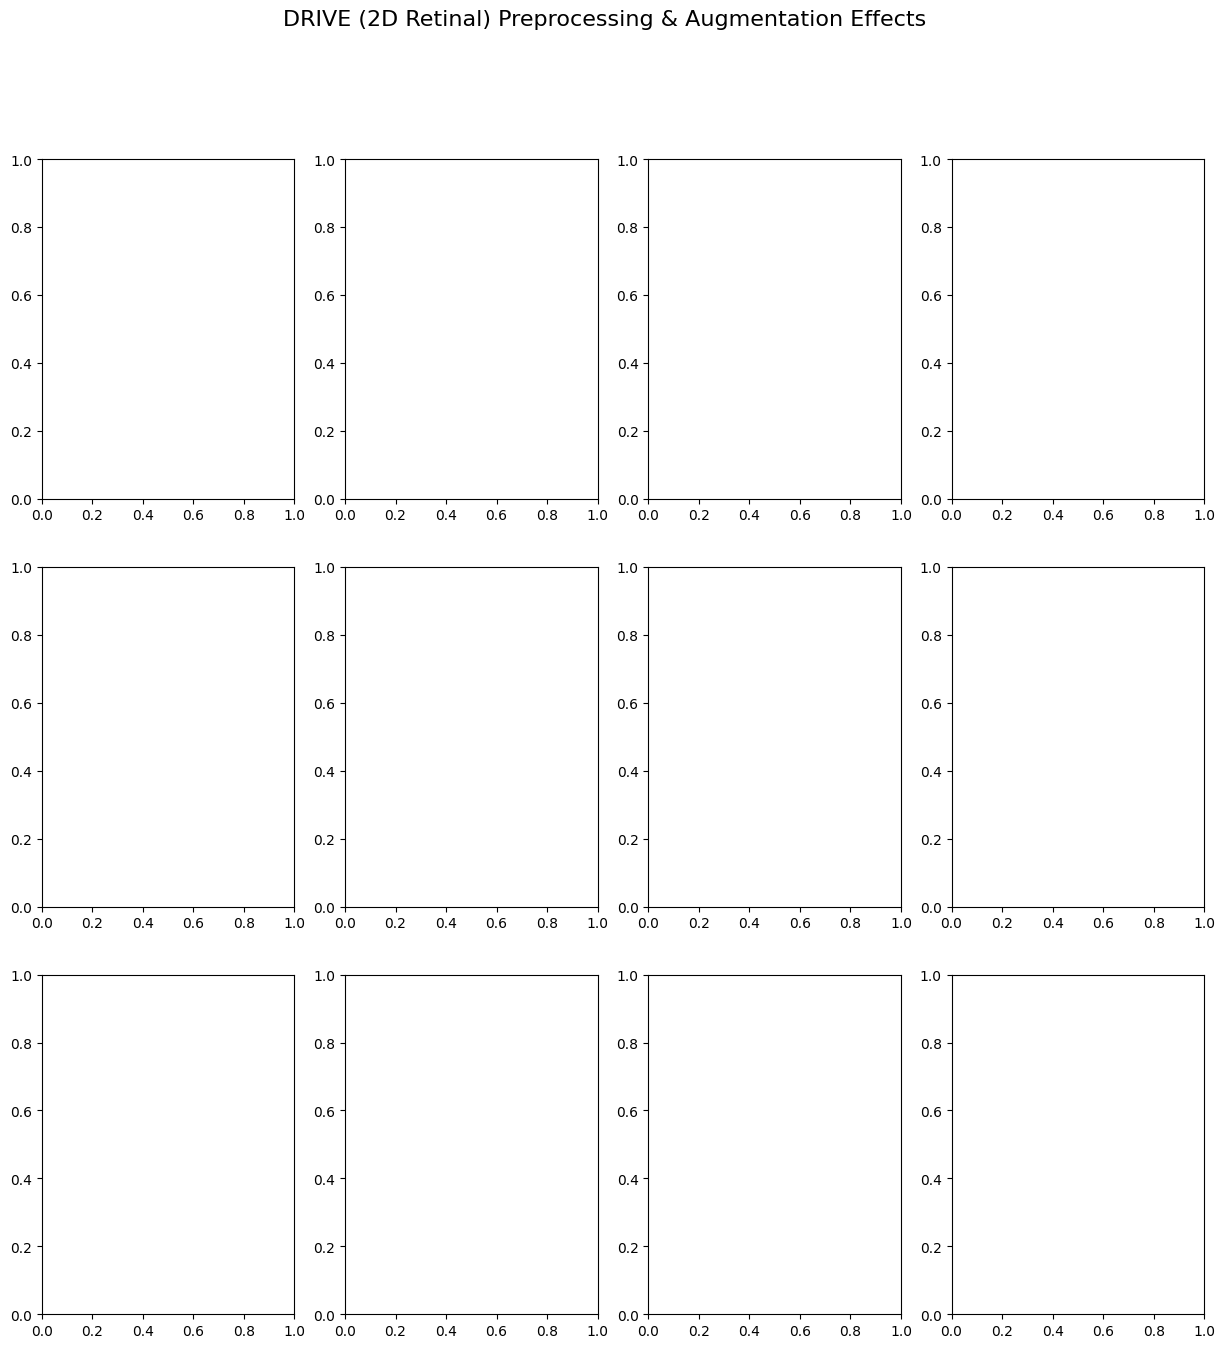

In [15]:
visualize_transforms(drive_train_files, DRIVE_TRAIN_TRANSFORM, num_samples=3, dataset_name="DRIVE (2D Retinal)")
